In [6]:
from ca_sae.sae.ca_sae import ClassAlignedSAE
import torch
import matplotlib.pyplot as plt

In [10]:
sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_tight_l0_agr//").cpu()
sae.eval()

ClassAlignedSAE(
  (decoder): Linear(in_features=4096, out_features=768, bias=False)
  (encoder): Linear(in_features=768, out_features=4096, bias=True)
  (k_estimator): Sequential(
    (0): Linear(in_features=768, out_features=4096, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4096, out_features=1, bias=True)
    (3): ReLU()
  )
)

In [11]:
ks = 5* 4096 *torch.softmax(sae.budget_vector, dim=0).detach().numpy()

(array([2.073e+03, 1.804e+03, 1.270e+02, 4.000e+01, 1.600e+01, 8.000e+00,
        1.000e+01, 2.000e+00, 3.000e+00, 1.000e+00, 3.000e+00, 0.000e+00,
        1.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]),
 array([  0.31862304,   4.34994125,   8.38125896,  12.41257668,
         16.44389534,  20.475214  ,  24.50653076,  28.53784943,
         32.56916809,  36.60048676,  40.63180542,  44.66312408,
         48.69443893,  52.7257576 ,  56.75707626,  60.78839493,
         64.81971741,  68.85103607,  72.88235474,  76.9136734 ,
         80.94499207,  84.97631073,  89.00762939,  93.03894806,
         97.07025909, 101.10157776, 105.13289642, 109.16421509,
        113.19553375, 117.22685242, 121.25817871]),
 <BarContainer object of 30 artists>)

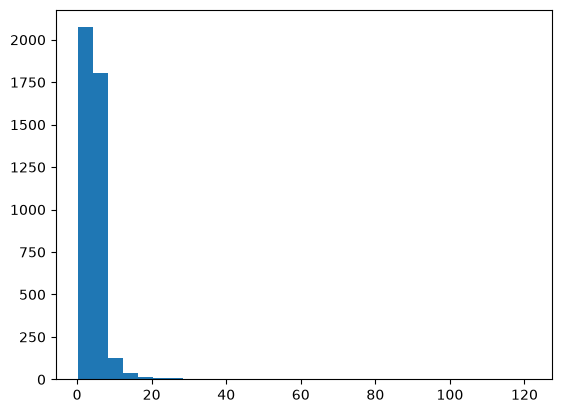

In [12]:
plt.hist(ks, bins=30)